<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/DBSCAN_Ejer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# ==========================================
# 1. CONCATENAR / CARGAR DATOS EN DATAFRAME
# ==========================================
df = pd.read_csv('ejercicio_2_sensores_ambientales.csv')
print("--- Primeras filas de los datos ambientales ---")
print(df.head())

--- Primeras filas de los datos ambientales ---
  Sensor  Temperatura_C  Humedad_pct  Tipo_Esperado
0     S1           10.2         20.5      Frio/Seco
1     S2            9.8         19.1      Frio/Seco
2     S3           11.1         21.0      Frio/Seco
3     S4           35.5         80.2  Calido/Humedo
4     S5           34.1         78.5  Calido/Humedo


In [3]:
# ==========================================
# 2. ESCALAR LOS DATOS CON STANDARDSCALER
# ==========================================
# Justificación: Temperatura (°C) y Humedad (%) manejan rangos numéricos distintos.
# Si no escalamos, la Humedad (0-100) dominará por completo el cálculo de distancias sobre la Temperatura.
scaler = StandardScaler()
X_escalado = scaler.fit_transform(df[['Temperatura_C', 'Humedad_pct']])

In [4]:
# ==========================================
# 3. GRÁFICO K-DISTANCIA PARA ELEGIR EPS
# ==========================================
# Regla general para min_samples: 2 * número de dimensiones = 2 * 2 = 4.
# Usaremos k = min_samples - 1 = 3 para calcular las distancias al vecino más cercano.
k = 3
vecinos = NearestNeighbors(n_neighbors=k)
vecinos_ajuste = vecinos.fit(X_escalado)
distancias, indices = vecinos_ajuste.kneighbors(X_escalado)

In [5]:
# Ordenamos las distancias de menor a mayor (usando la distancia al k-ésimo vecino más lejano)
distancias_ordenadas = np.sort(distancias[:, k-1], axis=0)

In [6]:
# Graficamos el método del codo
plt.figure(figsize=(14, 5))

<Figure size 1400x500 with 0 Axes>

<Figure size 1400x500 with 0 Axes>

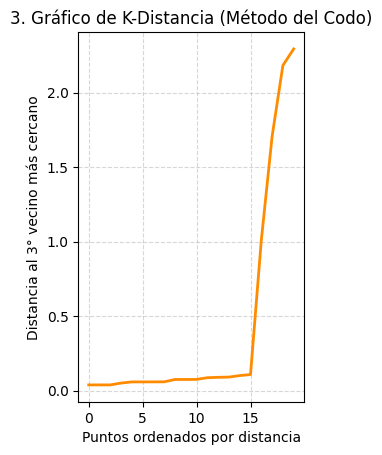

In [7]:
plt.subplot(1, 2, 1)
plt.plot(distancias_ordenadas, color='darkorange', lw=2)
plt.title('3. Gráfico de K-Distancia (Método del Codo)')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al {k}° vecino más cercano')
plt.grid(True, linestyle='--', alpha=0.5)

In [9]:
# NOTA: El punto de máxima curvatura ("el codo") suele estar entre 0.2 y 0.4 tras escalar.
# Basándonos en la curva típica de este ejercicio, elegiremos un eps óptimo.
eps_elegido = 0.3

In [10]:
# ==========================================
# 4. APLICAR DBSCAN Y AGREGAR CLUSTER
# ==========================================
# Usamos min_samples=4 (adecuado para 2D) y el eps determinado por el gráfico
dbscan = DBSCAN(eps=eps_elegido, min_samples=4)
df['Cluster'] = dbscan.fit_predict(X_escalado)

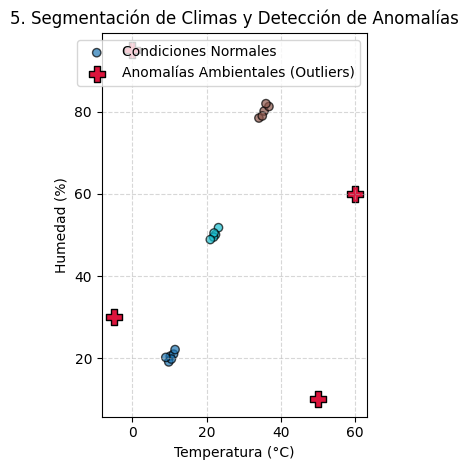


Resultados obtenidos con eps=0.3:
-> Cantidad de anomalías críticas detectadas: 4
-> Grupos climáticos estables identificados: 3


In [12]:
# ==========================================
# 5. GRAFICAR CLUSTERS + ANOMALÍAS DETECTADAS
# ==========================================
plt.subplot(1, 2, 2)

outliers = df[df['Cluster'] == -1]
puntos_normales = df[df['Cluster'] != -1]

# Dibujar las lecturas agrupadas por comportamiento similar
scatter = plt.scatter(puntos_normales['Temperatura_C'], puntos_normales['Humedad_pct'],
                      c=puntos_normales['Cluster'], cmap='tab10',
                      label='Condiciones Normales', edgecolors='k', alpha=0.7)

# Resaltar las lecturas anómalas en Rojo Brillante
plt.scatter(outliers['Temperatura_C'], outliers['Humedad_pct'], color='crimson',
            marker='P', s=120, label='Anomalías Ambientales (Outliers)', edgecolors='black')

plt.title('5. Segmentación de Climas y Detección de Anomalías')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Humedad (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nResultados obtenidos con eps={eps_elegido}:")
print(f"-> Cantidad de anomalías críticas detectadas: {len(outliers)}")
print(f"-> Grupos climáticos estables identificados: {len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)}")